# Basic Questions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
companies = ["AAPL", "TSLA", "GOOGL", "MSFT", "AMZN", "GE", "GS", "IBM", "JPM", "FB"]

data = {c: pd.read_csv(f"{c}.csv") for c in companies}

for c, df in data.items():

    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
    else:
        raise KeyError(f"File for {c} has no 'Date' column.")

    if 'Close(t)' not in df.columns and 'Close' in df.columns:
        df.rename(columns={'Close':'Close(t)'}, inplace=True)
    
    df.sort_values('Date', inplace=True)
    df.reset_index(drop=True, inplace=True)
    if 'Return' not in df.columns and 'Return(t)' not in df.columns:
        df['Return'] = df['Close(t)'].pct_change()
    elif 'Return(t)' in df.columns:
        df['Return'] = df['Return(t)']

    if 'Volatility' not in df.columns and 'Volatility(t)' not in df.columns and 'SD20' in df.columns:
        df['Volatility'] = df['SD20'] 
    if 'Volatility' not in df.columns and 'Volatility(t)' not in df.columns:
        df['Volatility'] = df['Return'].rolling(window=20, min_periods=5).std()
    
    if 'MACD' not in df.columns:
        df['MACD'] = np.nan
    if 'MACD_EMA' not in df.columns and 'MACD_EMA' not in df.columns:
        
        df['MACD_EMA'] = df.get('MACD_EMA', np.nan)
    if 'RSI' not in df.columns:
        df['RSI'] = np.nan
    data[c] = df


In [3]:
# Task 1: Average closing price for each company
avg_close = {c: round(data[c]['Close(t)'].mean(), 2) for c in companies}

print("1. Average Closing Price of Each Company:\n")
print(f"{'Company':<10}{'Average Closing Price (USD)':>30}")
print("-" * 40)
for company, price in avg_close.items():
    print(f"{company:<10}{price:>20.2f}")

1. Average Closing Price of Each Company:

Company      Average Closing Price (USD)
----------------------------------------
AAPL                     87.26
TSLA                    351.71
GOOGL                   615.84
MSFT                     48.38
AMZN                    826.20
GE                       17.58
GS                      157.25
IBM                      98.46
JPM                      45.13
FB                      161.35


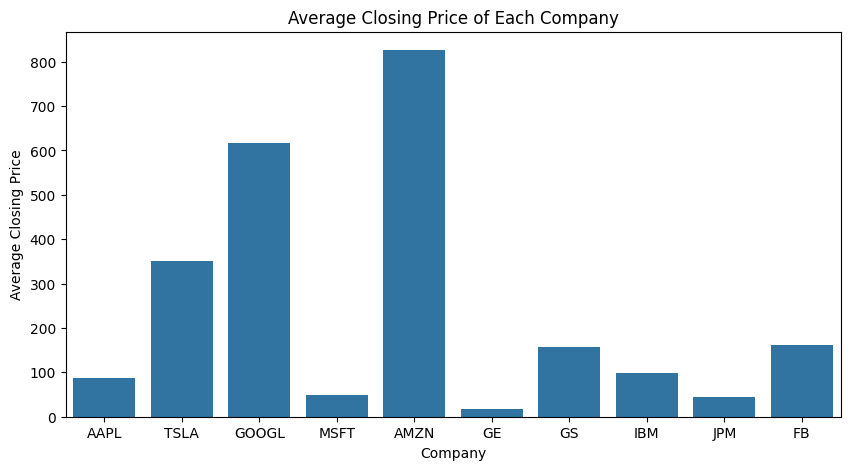

In [4]:
plt.figure(figsize=(10,5))
sns.barplot(x=list(avg_close.keys()), y=list(avg_close.values()))
plt.title("Average Closing Price of Each Company")
plt.ylabel("Average Closing Price")
plt.xlabel("Company")
plt.show()

In [5]:
max_close = {c: data[c]['Close(t)'].max() for c in companies}
company_highest_close = max(max_close, key=max_close.get)
print(f"\n2. Company with highest single-day closing price: {company_highest_close} ({max_close[company_highest_close]:.2f} USD)")


2. Company with highest single-day closing price: AMZN (3225.00 USD)


In [6]:
# 3. Company with lowest average daily return (using Close(t) percent change)
avg_return = {c: data[c]['Close(t)'].pct_change().mean() for c in companies}
lowest_avg_return = min(avg_return, key=avg_return.get)
print(f"\n3. Company with lowest average return: {lowest_avg_return} ({avg_return[lowest_avg_return]:.6f})")


3. Company with lowest average return: GE (-0.000083)


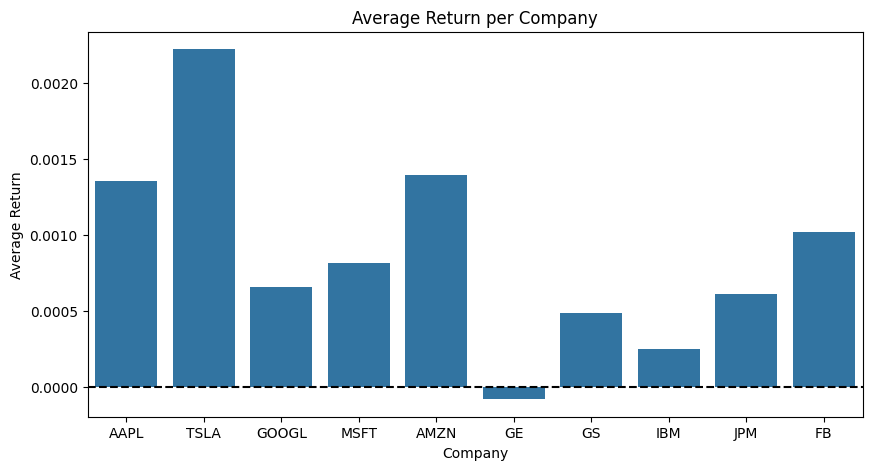

In [7]:
plt.figure(figsize=(10,5))
sns.barplot(x=list(avg_return.keys()), y=list(avg_return.values()))
plt.title("Average Return per Company")
plt.ylabel("Average Return")
plt.xlabel("Company")
plt.axhline(0, color='black', linestyle='--')
plt.show()

In [8]:
# 4. Tesla highest closing price date
tsla_max_close_date = data['TSLA'].loc[data['TSLA']['Close(t)'].idxmax(), 'Date']
print(f"\n4. Date Tesla recorded highest closing price: {tsla_max_close_date}")


4. Date Tesla recorded highest closing price: 2020-07-20 00:00:00


In [9]:
# 5. Total trading days for each company
trading_days = {c: len(data[c]) for c in companies}
print("\n5. Total Trading Days for Each Company:")
print(f"{'Company':<10}{'Trading Days':>20}")
print("-" * 30)
for c, days in trading_days.items():
    print(f"{c:<10}{days:>15}")


5. Total Trading Days for Each Company:
Company           Trading Days
------------------------------
AAPL                 3732
TSLA                 1215
GOOGL                3229
MSFT                 3732
AMZN                 2473
GE                   4988
GS                   3732
IBM                  4988
JPM                  4988
FB                   1215


In [10]:
# 6. Average daily trading volume for Apple
aapl_avg_volume = round(data['AAPL']['Volume'].mean(), 2)
print(f"\n6. Average daily trading volume for Apple (AAPL): {aapl_avg_volume}")


6. Average daily trading volume for Apple (AAPL): 114334961.15


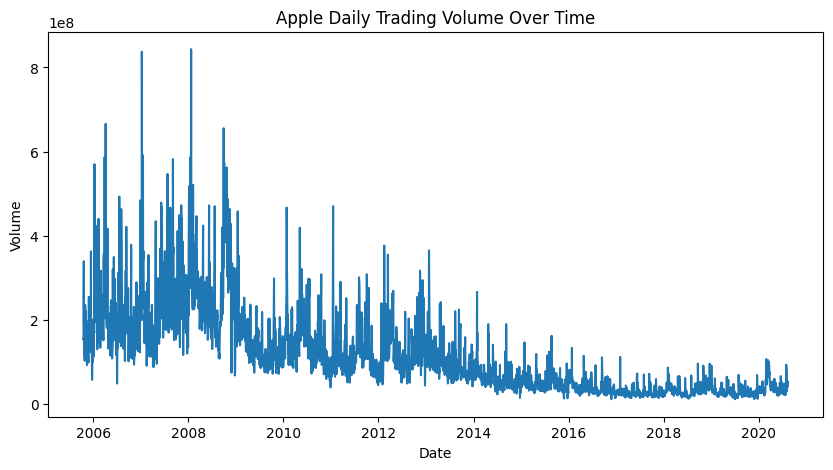

In [11]:
plt.figure(figsize=(10,5))
plt.plot(data['AAPL']['Date'], data['AAPL']['Volume'])
plt.title("Apple Daily Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

In [12]:
# 7. Company with highest overall average volatility
avg_volatility = {c: (data[c]['High'] - data[c]['Low']).mean() for c in companies}
highest_vol_company = max(avg_volatility, key=avg_volatility.get)
print(f"\n7. Company with highest average volatility: {highest_vol_company} ({avg_volatility[highest_vol_company]:.2f})")


7. Company with highest average volatility: AMZN (18.08)


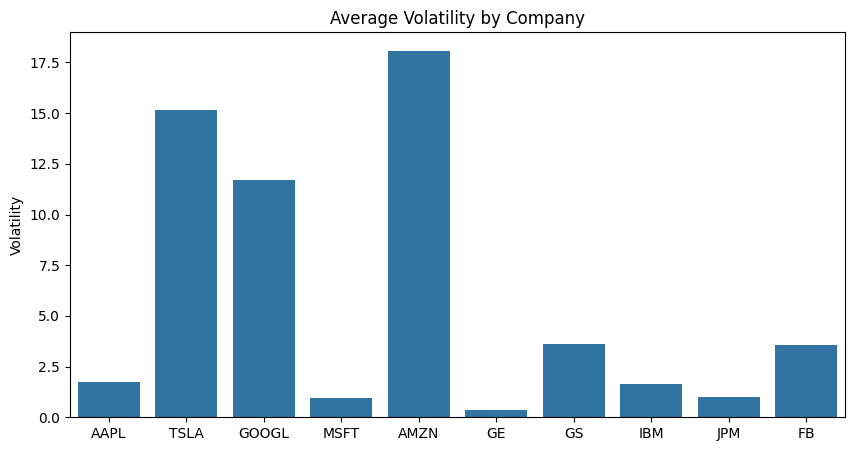

In [13]:
plt.figure(figsize=(10,5))
sns.barplot(x=list(avg_volatility.keys()), y=list(avg_volatility.values()))
plt.title("Average Volatility by Company")
plt.ylabel("Volatility")
plt.show()

In [14]:
# 8. Average and median closing price for Google
googl_avg = round(data['GOOGL']['Close(t)'].mean(), 2)
googl_median = round(data['GOOGL']['Close(t)'].median(), 2)
print(f"\n8. Google (GOOGL) Average Close: {googl_avg}, Median Close: {googl_median}")


8. Google (GOOGL) Average Close: 615.84, Median Close: 537.76


In [15]:
# 9. Days Microsoft recorded positive daily returns
msft_positive_days = (data['MSFT']['Close(t)'].pct_change() > 0).sum()
print(f"\n9. Microsoft positive daily return days: {msft_positive_days}")


9. Microsoft positive daily return days: 1920


In [16]:
avg_rsi = {c: data[c]['RSI'].mean() if 'RSI' in data[c].columns else np.nan for c in companies}
avg_rsi = {k: v for k, v in avg_rsi.items() if not np.isnan(v)}
highest_rsi_company = max(avg_rsi, key=avg_rsi.get)
print(f"\n10. Company with highest average RSI: {highest_rsi_company} ({avg_rsi[highest_rsi_company]:.2f})")



10. Company with highest average RSI: AAPL (56.02)


In [17]:
# 11. Min, Max, Mean daily return for Amazon
amzn_returns = data['AMZN']['Close(t)'].pct_change()
print("\n11. Amazon (AMZN) Daily Return Statistics:")
print(f"   Min: {amzn_returns.min():.4f}, Max: {amzn_returns.max():.4f}, Mean: {amzn_returns.mean():.4f}")


11. Amazon (AMZN) Daily Return Statistics:
   Min: -0.1266, Max: 0.1575, Mean: 0.0014


In [18]:
# 12. Company with largest range between highest & lowest daily prices
price_range = {c: data[c]['Close(t)'].max() - data[c]['Close(t)'].min() for c in companies}
largest_range_company = max(price_range, key=price_range.get)
print(f"\n12. Company with largest price range: {largest_range_company} ({price_range[largest_range_company]:.2f})")


12. Company with largest price range: AMZN (3067.22)


In [19]:
# 13. How often GE closed higher than it opened
ge_close_higher = (data['GE']['Close(t)'] > data['GE']['Open']).sum()
print(f"\n13. GE closed higher than opened on {ge_close_higher} days")


13. GE closed higher than opened on 2342 days


In [20]:
# 14. Company with highest total trading volume
total_volume = {c: data[c]['Volume'].sum() for c in companies}
highest_volume_company = max(total_volume, key=total_volume.get)
print(f"\n14. Company with highest total trading volume: {highest_volume_company} ({total_volume[highest_volume_company]:,.0f})")


14. Company with highest total trading volume: AAPL (426,698,075,000)


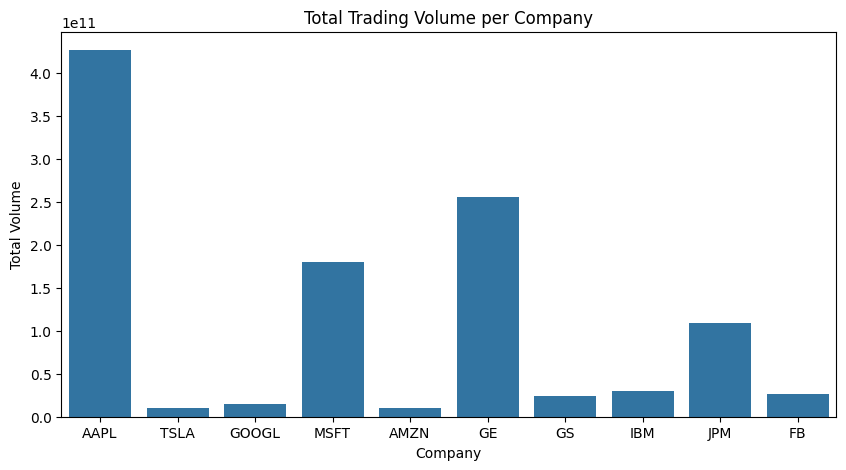

In [21]:
plt.figure(figsize=(10,5))
sns.barplot(x=list(total_volume.keys()), y=list(total_volume.values()))
plt.title("Total Trading Volume per Company")
plt.ylabel("Total Volume")
plt.xlabel("Company")
plt.show()

# intermediate questions

In [22]:
sns.set(style="whitegrid", context="notebook", rc={"figure.figsize": (10,5)})


15. Average return in the last quarter (descending):
TSLA     0.011675
AAPL     0.006274
AMZN     0.004734
FB       0.003666
GS       0.003032
JPM      0.003029
MSFT     0.002280
GE       0.002232
GOOGL    0.001631
IBM      0.001002
dtype: float64


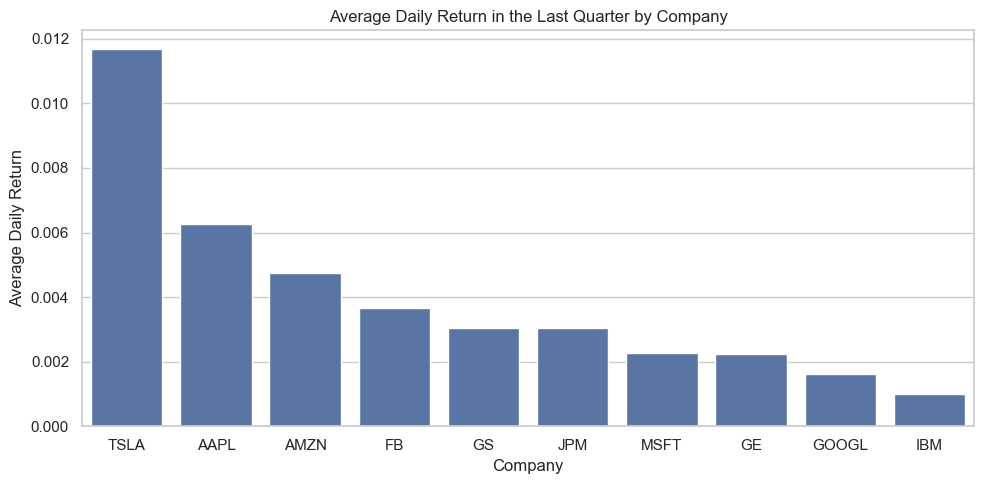

In [23]:
avg_returns_last_q = {}
for c, df in data.items():
    last_date = df['Date'].max()
    start_q = last_date - pd.DateOffset(months=3)
    df_q = df[df['Date'] >= start_q].copy()
    avg_returns_last_q[c] = df_q['Return'].mean()

avg_returns_last_q = pd.Series(avg_returns_last_q).sort_values(ascending=False)
print("15. Average return in the last quarter (descending):")
print(avg_returns_last_q.round(6))

plt.figure(figsize=(10,5))
sns.barplot(x=avg_returns_last_q.index, y=avg_returns_last_q.values)
plt.title("Average Daily Return in the Last Quarter by Company")
plt.ylabel("Average Daily Return")
plt.xlabel("Company")
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()


16. Average trading volume (by company):
AAPL     1.143350e+08
MSFT     4.823395e+07
GOOGL    4.489683e+06
FB       2.193150e+07
GS       6.414935e+06
JPM      2.175034e+07
dtype: float64


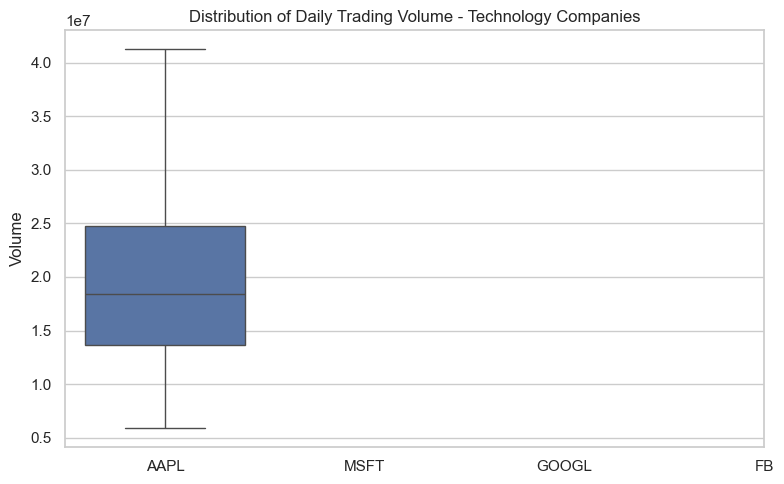

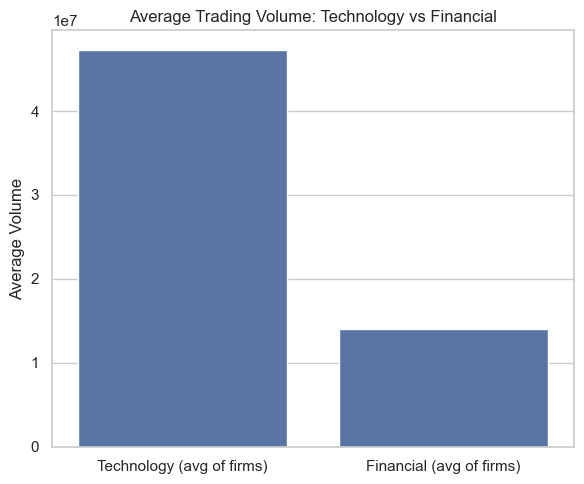

In [24]:
tech = ['AAPL', 'MSFT', 'GOOGL', 'FB']
finance = ['GS', 'JPM']
avg_vol_tech = pd.Series({c: data[c]['Volume'].mean() for c in tech})
avg_vol_fin = pd.Series({c: data[c]['Volume'].mean() for c in finance})

print("\n16. Average trading volume (by company):")
print(pd.concat([avg_vol_tech, avg_vol_fin]))

plt.figure(figsize=(8,5))
sns.boxplot(data=[data[c]['Volume'].dropna() for c in tech], showfliers=False)
plt.xticks(range(len(tech)), tech)
plt.title("Distribution of Daily Trading Volume - Technology Companies")
plt.ylabel("Volume")
plt.tight_layout()
plt.show()


plt.figure(figsize=(6,5))
sns.barplot(x=['Technology (avg of firms)', 'Financial (avg of firms)'],
            y=[avg_vol_tech.mean(), avg_vol_fin.mean()])
plt.title("Average Trading Volume: Technology vs Financial")
plt.ylabel("Average Volume")
plt.tight_layout()
plt.show()


17. Standard deviation of daily returns (ascending):
IBM      0.016172
MSFT     0.017541
GOOGL    0.018698
AMZN     0.019803
FB       0.020278
AAPL     0.020671
GE       0.020973
GS       0.023729
JPM      0.024710
TSLA     0.034826
dtype: float64


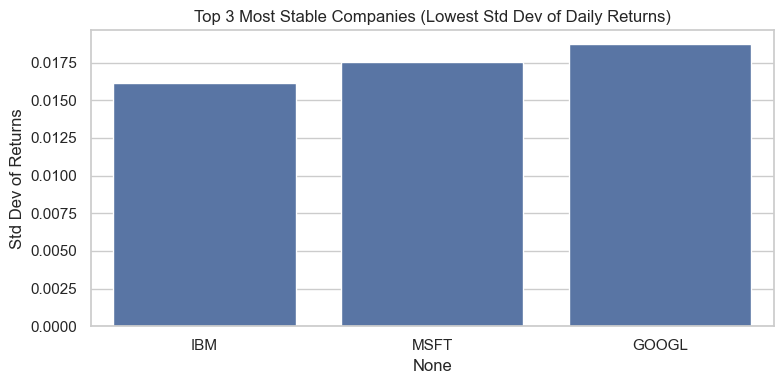

In [25]:

std_returns = pd.Series({c: data[c]['Return'].std() for c in companies}).sort_values()
print("\n17. Standard deviation of daily returns (ascending):")
print(std_returns.round(6))
stable_three = std_returns.head(3)
plt.figure(figsize=(8,4))
sns.barplot(x=stable_three.index, y=stable_three.values)
plt.title("Top 3 Most Stable Companies (Lowest Std Dev of Daily Returns)")
plt.ylabel("Std Dev of Returns")
plt.tight_layout()
plt.show()

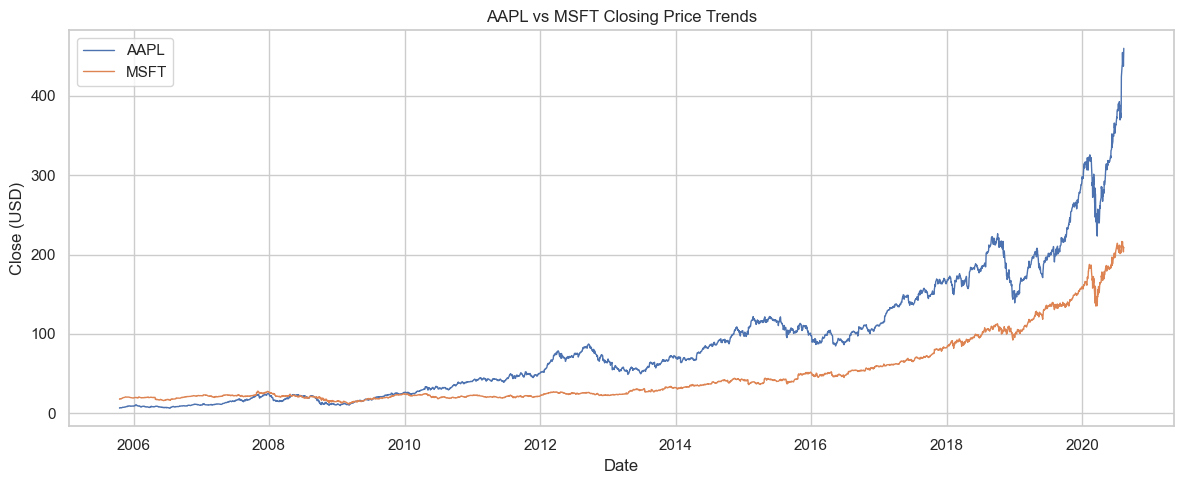

In [26]:
plt.figure(figsize=(12,5))
plt.plot(data['AAPL']['Date'], data['AAPL']['Close(t)'], label='AAPL', linewidth=1)
plt.plot(data['MSFT']['Date'], data['MSFT']['Close(t)'], label='MSFT', linewidth=1)
plt.title("AAPL vs MSFT Closing Price Trends")
plt.xlabel("Date")
plt.ylabel("Close (USD)")
plt.legend()
plt.tight_layout()
plt.show()

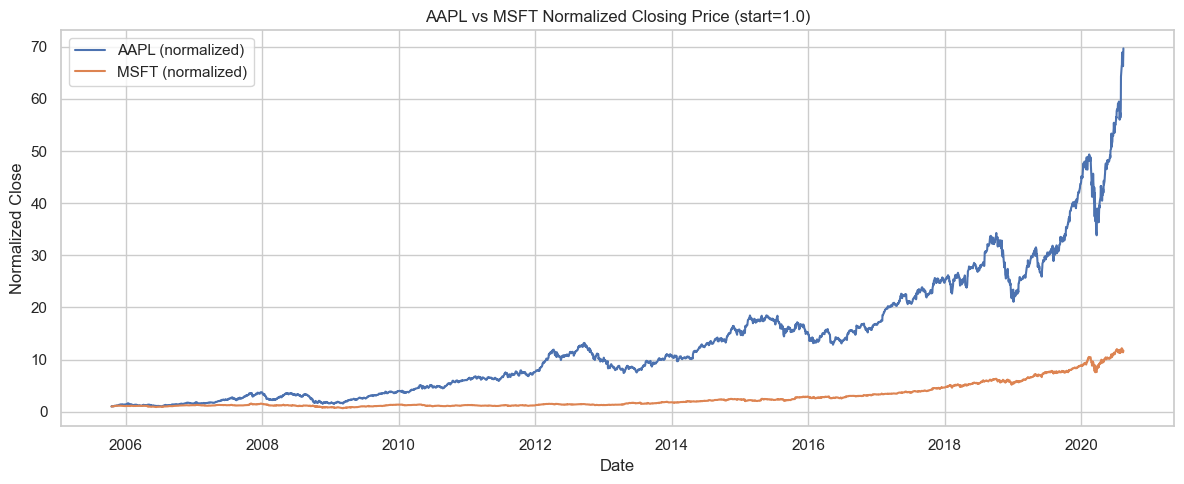

In [27]:
plt.figure(figsize=(12,5))
aapl_norm = data['AAPL']['Close(t)'] / data['AAPL']['Close(t)'].iloc[0]
msft_norm = data['MSFT']['Close(t)'] / data['MSFT']['Close(t)'].iloc[0]
plt.plot(data['AAPL']['Date'], aapl_norm, label='AAPL (normalized)')
plt.plot(data['MSFT']['Date'], msft_norm, label='MSFT (normalized)')
plt.title("AAPL vs MSFT Normalized Closing Price (start=1.0)")
plt.xlabel("Date")
plt.ylabel("Normalized Close")
plt.legend()
plt.tight_layout()
plt.show()


19. Correlation (Volume vs Daily Return):
AAPL    -0.0227
TSLA     0.1059
GOOGL   -0.0261
MSFT    -0.0714
AMZN     0.0160
GE      -0.0238
GS      -0.0342
IBM     -0.0553
JPM      0.0307
FB      -0.0780
dtype: float64


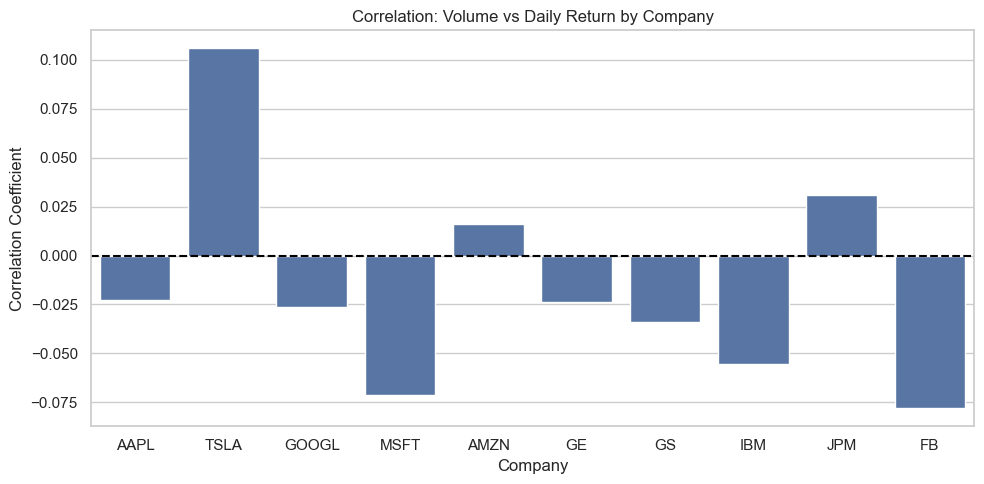

In [28]:
vol_return_corr = pd.Series({c: data[c].loc[:, ['Volume','Return']].dropna().corr().loc['Volume','Return']
                             for c in companies})
print("\n19. Correlation (Volume vs Daily Return):")
print(vol_return_corr.round(4))

plt.figure(figsize=(10,5))
sns.barplot(x=vol_return_corr.index, y=vol_return_corr.values)
plt.title("Correlation: Volume vs Daily Return by Company")
plt.ylabel("Correlation Coefficient")
plt.xlabel("Company")
plt.axhline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()



20. Change in volatility (6-month recent mean - earlier mean):
GE       0.029207
TSLA     0.028430
JPM      0.021258
GS       0.020521
MSFT     0.015999
IBM      0.015382
FB       0.014962
AAPL     0.012207
GOOGL    0.010964
AMZN     0.008205
dtype: float64


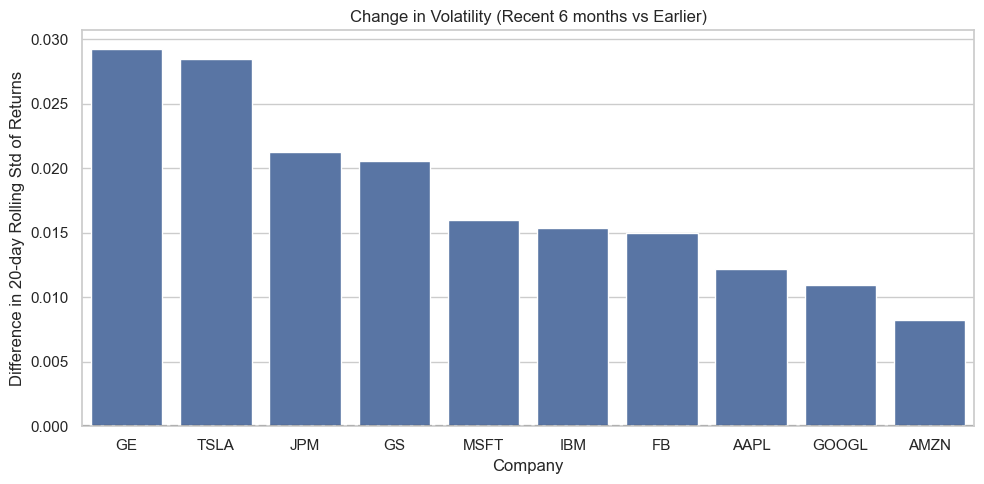

In [29]:
vol_change = {}
for c, df in data.items():
    df = df.copy()
    last_date = df['Date'].max()
    mid_date = last_date - pd.DateOffset(months=6)
    recent = df[df['Date'] > mid_date]['Return'].rolling(20, min_periods=5).std()
    earlier = df[df['Date'] <= mid_date]['Return'].rolling(20, min_periods=5).std()
    
    vol_change[c] = recent.mean() - earlier.mean()
vol_change = pd.Series(vol_change).sort_values(ascending=False)
print("\n20. Change in volatility (6-month recent mean - earlier mean):")
print(vol_change.round(6))

plt.figure(figsize=(10,5))
sns.barplot(x=vol_change.index, y=vol_change.values)
plt.title("Change in Volatility (Recent 6 months vs Earlier)")
plt.ylabel("Difference in 20-day Rolling Std of Returns")
plt.xlabel("Company")
plt.axhline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

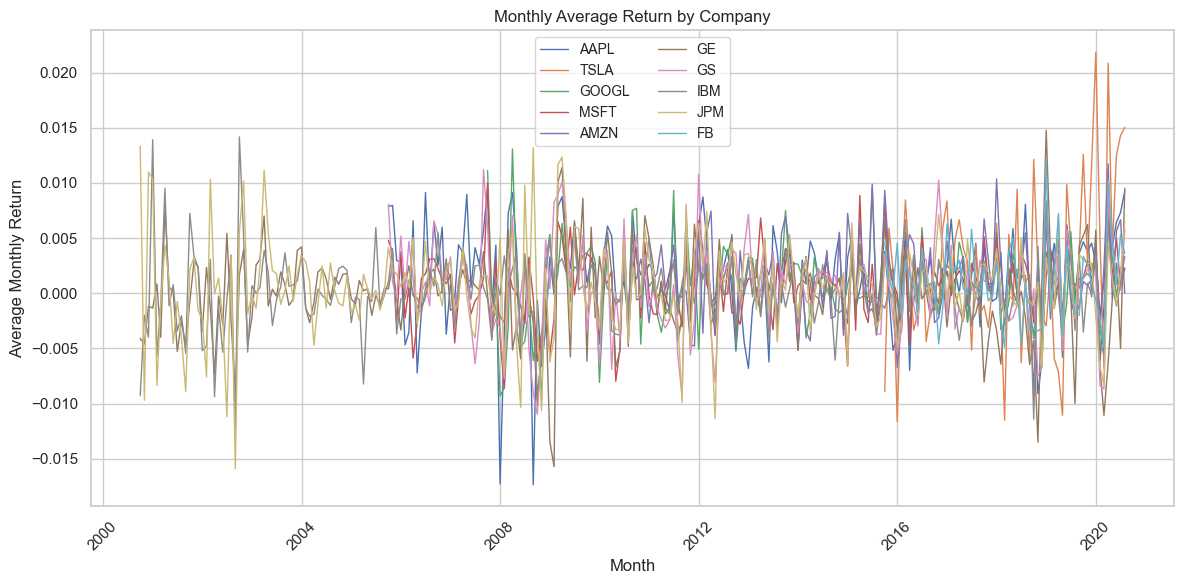

In [30]:
monthly_avg_returns = {}
for c, df in data.items():
    df = df.copy()
    df['Month'] = df['Date'].dt.to_period('M')
    monthly = df.groupby('Month')['Return'].mean()
    monthly_avg_returns[c] = monthly
monthly_df = pd.DataFrame({c: s for c, s in monthly_avg_returns.items()})
monthly_df.index = monthly_df.index.to_timestamp()

plt.figure(figsize=(12,6))
for c in companies:
    plt.plot(monthly_df.index, monthly_df[c], label=c, linewidth=1)
plt.title("Monthly Average Return by Company")
plt.xlabel("Month")
plt.ylabel("Average Monthly Return")
plt.legend(ncol=2, fontsize='small')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


22. Bullish MACD signal counts (MACD > MACD_EMA):
IBM      2536
GE       2485
JPM      2456
AAPL     1948
MSFT     1941
GS       1911
GOOGL    1674
AMZN     1217
TSLA      663
FB        604
dtype: int64


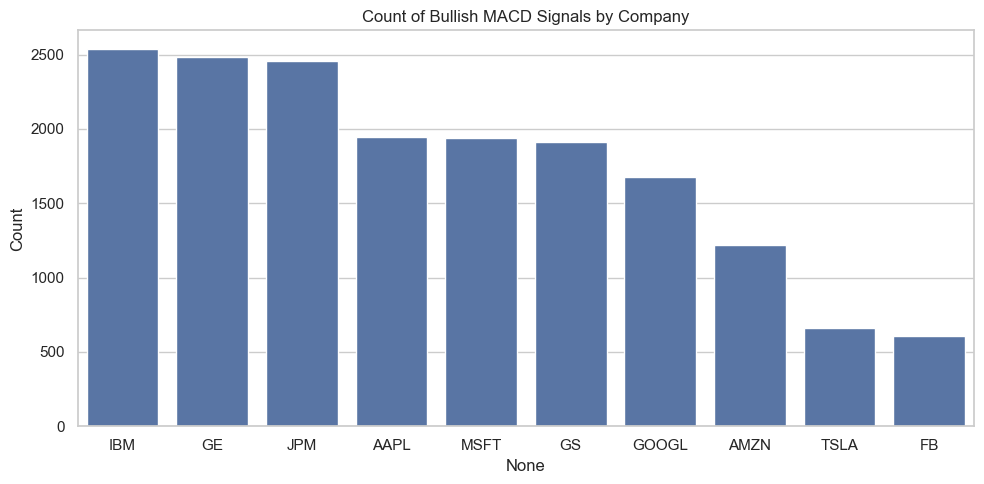

In [31]:
macd_counts = {}
for c, df in data.items():
    if 'MACD' in df.columns and 'MACD_EMA' in df.columns:
        macd_counts[c] = ((df['MACD'] > df['MACD_EMA']).sum())
    else:
        macd_counts[c] = np.nan
macd_counts = pd.Series(macd_counts).sort_values(ascending=False)
print("\n22. Bullish MACD signal counts (MACD > MACD_EMA):")
print(macd_counts)

plt.figure(figsize=(10,5))
sns.barplot(x=macd_counts.index, y=macd_counts.values)
plt.title("Count of Bullish MACD Signals by Company")
plt.ylabel("Count")
plt.tight_layout()
plt.show()



23. Average RSI vs Average Return:
           Avg_RSI  Avg_Return
Company                       
AAPL     56.015693    0.001352
TSLA     53.005610    0.002223
GOOGL    53.732822    0.000658
MSFT     54.460557    0.000813
AMZN     55.607716    0.001394
GE       50.251243   -0.000083
GS       52.234076    0.000484
IBM      51.517936    0.000245
JPM      52.600083    0.000611
FB       54.833036    0.001019


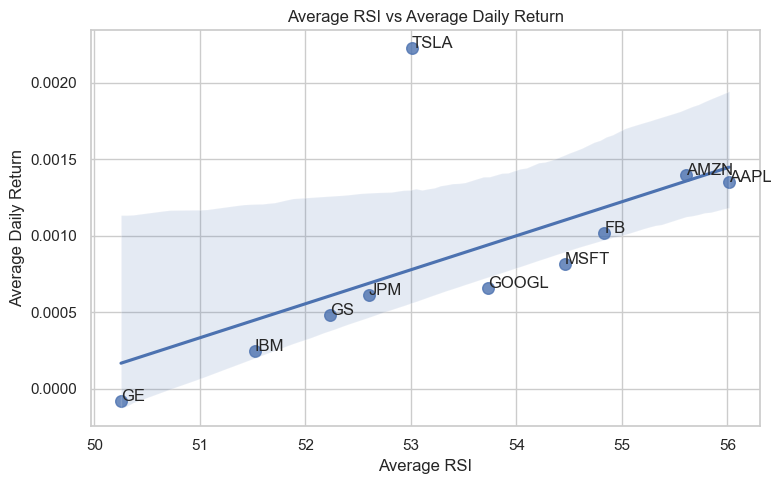

In [32]:
rsi_return_df = pd.DataFrame({
    'Company': companies,
    'Avg_RSI': [data[c]['RSI'].mean() for c in companies],
    'Avg_Return': [data[c]['Return'].mean() for c in companies]
})
print("\n23. Average RSI vs Average Return:")
print(rsi_return_df.set_index('Company').round(6))

plt.figure(figsize=(8,5))
sns.regplot(x='Avg_RSI', y='Avg_Return', data=rsi_return_df, scatter_kws={'s':70})
for i, row in rsi_return_df.iterrows():
    plt.text(row['Avg_RSI'], row['Avg_Return'], rsi_return_df.loc[i, 'Company'])
plt.title("Average RSI vs Average Daily Return")
plt.xlabel("Average RSI")
plt.ylabel("Average Daily Return")
plt.tight_layout()
plt.show()


24. Recovery days from trough to 90% of prior peak (ascending):
TSLA       64
AMZN      102
FB        191
AAPL      239
MSFT     1066
GOOGL    1136
JPM      1232
IBM      1682
GS       2370
GE       2580
dtype: int64


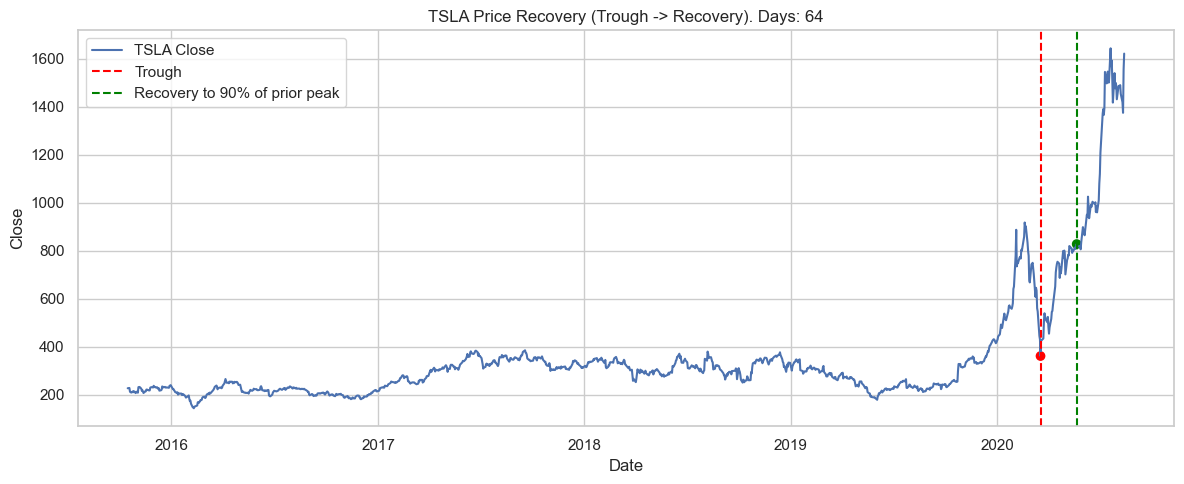

In [33]:
recovery_days = {}
recovery_info = {}
for c, df in data.items():
    prices = df.set_index('Date')['Close(t)'].copy()
    roll_max = prices.cummax()
    drawdown = (prices / roll_max) - 1
    trough_date = drawdown.idxmin()
    trough_price = prices.loc[trough_date]
    prior_peak_price = roll_max.loc[:trough_date].max()
    target = 0.9 * prior_peak_price
    after = prices[prices.index > trough_date]
    if not after.empty and (after >= target).any():
        recovery_date = after[after >= target].index.min()
        recovery_days[c] = (recovery_date - trough_date).days
        recovery_info[c] = (trough_date, trough_price, prior_peak_price, recovery_date)
    else:
        recovery_days[c] = np.nan
recovery_series = pd.Series(recovery_days).dropna().sort_values()
print("\n24. Recovery days from trough to 90% of prior peak (ascending):")
print(recovery_series.round(1))

if not recovery_series.empty:
    fastest = recovery_series.index[0]
    trough_date, trough_price, prior_peak, recovery_date = recovery_info[fastest]
    df_plot = data[fastest].set_index('Date')['Close(t)']
    plt.figure(figsize=(12,5))
    plt.plot(df_plot.index, df_plot.values, label=f"{fastest} Close")
    plt.axvline(trough_date, color='red', linestyle='--', label='Trough')
    plt.axvline(recovery_date, color='green', linestyle='--', label='Recovery to 90% of prior peak')
    plt.scatter([trough_date, recovery_date], [trough_price, df_plot.loc[recovery_date]], color=['red','green'])
    plt.title(f"{fastest} Price Recovery (Trough -> Recovery). Days: {int(recovery_series.iloc[0])}")
    plt.xlabel("Date")
    plt.ylabel("Close")
    plt.legend()
    plt.tight_layout()
    plt.show()


25. Top tech: AAPL (avg return 0.001352), Top financial: JPM (avg return 0.000611)


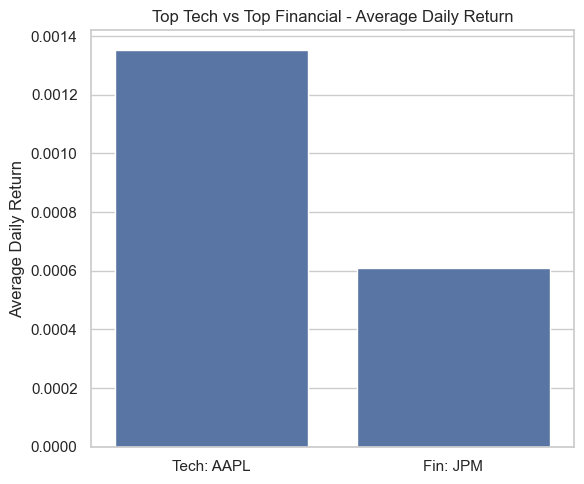

In [34]:
tech_companies = ['AAPL', 'MSFT', 'GOOGL', 'FB']
financial_companies = ['GS', 'JPM']
tech_avg = {c: data[c]['Return'].mean() for c in tech_companies}
fin_avg = {c: data[c]['Return'].mean() for c in financial_companies}
top_tech = max(tech_avg, key=tech_avg.get)
top_fin = max(fin_avg, key=fin_avg.get)
print(f"\n25. Top tech: {top_tech} (avg return {tech_avg[top_tech]:.6f}), Top financial: {top_fin} (avg return {fin_avg[top_fin]:.6f})")
plt.figure(figsize=(6,5))
sns.barplot(x=[f"Tech: {top_tech}", f"Fin: {top_fin}"], y=[tech_avg[top_tech], fin_avg[top_fin]])
plt.title("Top Tech vs Top Financial - Average Daily Return")
plt.ylabel("Average Daily Return")
plt.tight_layout()
plt.show()


26. Correlation matrix (returns):


,AAPL,TSLA,GOOGL,MSFT,AMZN,GE,GS,IBM,JPM,FB
AAPL,1.0000,0.3663,0.5810,0.5094,0.4255,0.4079,0.4588,0.4773,0.4327,0.5714
TSLA,0.3663,1.0000,0.3819,0.4012,0.3671,0.2434,0.3343,0.2845,0.2845,0.3296
GOOGL,0.5810,0.3819,1.0000,0.6002,0.5685,0.4234,0.5069,0.4963,0.4808,0.6924
MSFT,0.5094,0.4012,0.6002,1.0000,0.5142,0.4277,0.5127,0.5569,0.4846,0.6228
AMZN,0.4255,0.3671,0.5685,0.5142,1.0000,0.2769,0.3610,0.3634,0.3307,0.6141
GE,0.4079,0.2434,0.4234,0.4277,0.2769,1.0000,0.5248,0.5072,0.6089,0.3235
GS,0.4588,0.3343,0.5069,0.5127,0.3610,0.5248,1.0000,0.5265,0.7628,0.4539
IBM,0.4773,0.2845,0.4963,0.5569,0.3634,0.5072,0.5265,1.0000,0.5147,0.3881
JPM,0.4327,0.2845,0.4808,0.4846,0.3307,0.6089,0.7628,0.5147,1.0000,0.4216
FB,0.5714,0.3296,0.6924,0.6228,0.6141,0.3235,0.4539,0.3881,0.4216,1.0000


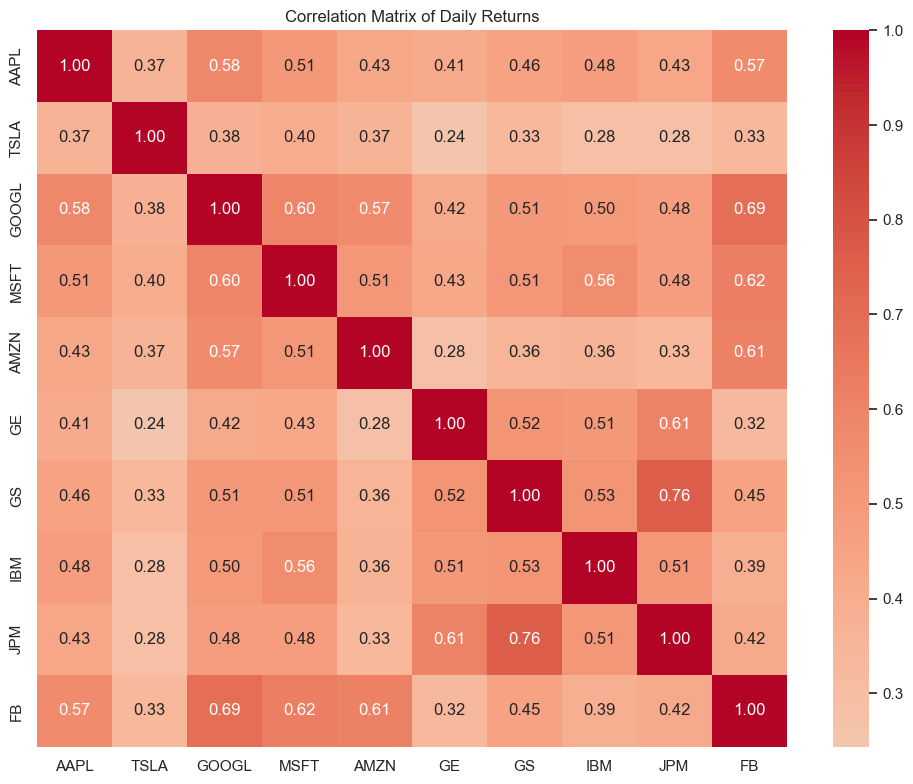


Top 3 strongest correlated company pairs (by daily returns):
Series([], dtype: float64)


In [35]:
returns_df = pd.DataFrame({c: data[c].set_index('Date')['Return'] for c in companies})
corr_matrix = returns_df.corr()
print("\n26. Correlation matrix (returns):")
display(corr_matrix.round(4))

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Correlation Matrix of Daily Returns")
plt.tight_layout()
plt.show()

# list top 3 pairwise correlations (excluding self)
corr_pairs = corr_matrix.unstack().dropna()
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]
corr_pairs = corr_pairs[corr_pairs.index.duplicated(keep='first')]
top_pairs = corr_pairs.sort_values(ascending=False).head(3)
print("\nTop 3 strongest correlated company pairs (by daily returns):")
print(top_pairs.round(4))


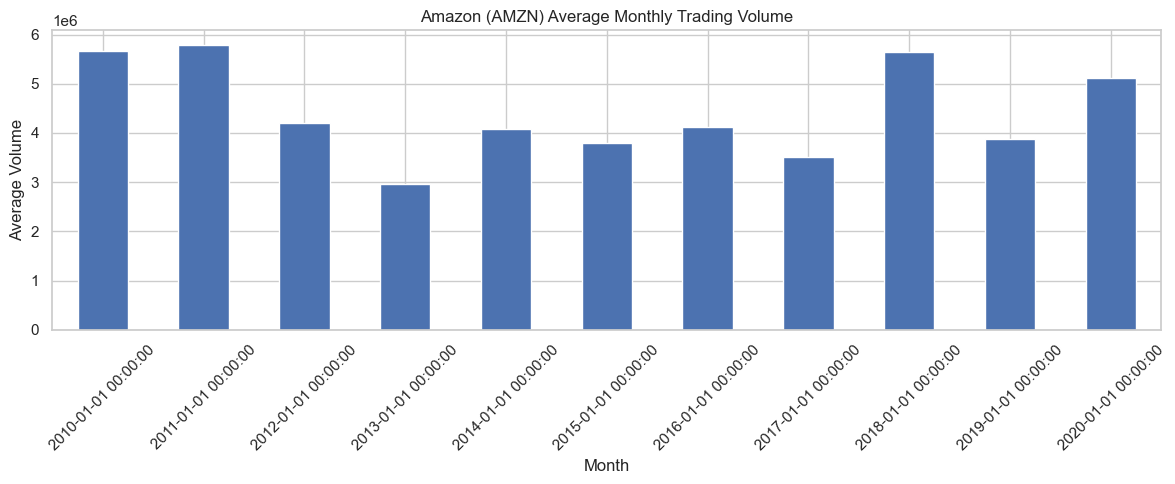

In [36]:
amzn = data['AMZN'].copy()
amzn['Year'] = amzn['Date'].dt.to_period('Y')
monthly_vol_amzn = amzn.groupby('Year')['Volume'].mean()
monthly_vol_amzn.index = monthly_vol_amzn.index.to_timestamp()

plt.figure(figsize=(12,5))
monthly_vol_amzn.plot(kind='bar')
plt.title("Amazon (AMZN) Average Monthly Trading Volume")
plt.xlabel("Month")
plt.ylabel("Average Volume")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


28. Largest single-week drop (min weekly return):
JPM     -0.3410
GS      -0.3062
TSLA    -0.2586
AAPL    -0.2432
GE      -0.2047
MSFT    -0.1835
FB      -0.1670
IBM     -0.1549
GOOGL   -0.1535
AMZN    -0.1446
dtype: float64


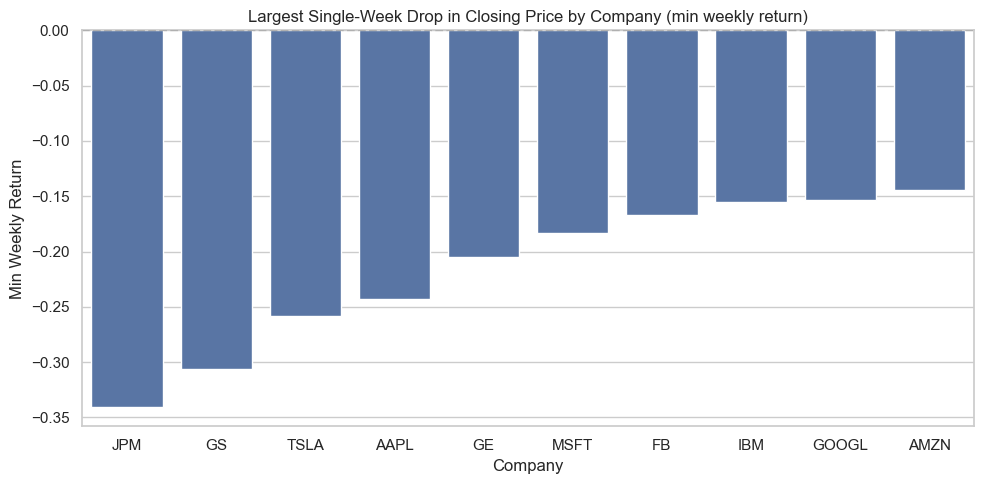

In [37]:
weekly_min_returns = {}
for c, df in data.items():
    dfw = df.set_index('Date').resample('W')['Close(t)'].last().pct_change()
    weekly_min_returns[c] = dfw.min()
weekly_min_series = pd.Series(weekly_min_returns).sort_values()
print("\n28. Largest single-week drop (min weekly return):")
print(weekly_min_series.round(4))

plt.figure(figsize=(10,5))
sns.barplot(x=weekly_min_series.index, y=weekly_min_series.values)
plt.title("Largest Single-Week Drop in Closing Price by Company (min weekly return)")
plt.ylabel("Min Weekly Return")
plt.xlabel("Company")
plt.axhline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

# High level Questions

In [39]:
def plot_series(df, x='Date', y='value', title=None, label=None):
    
    plt.tight_layout()
    plt.show()

29) AAPL: Trend and moving averages (7-day, 30-day)


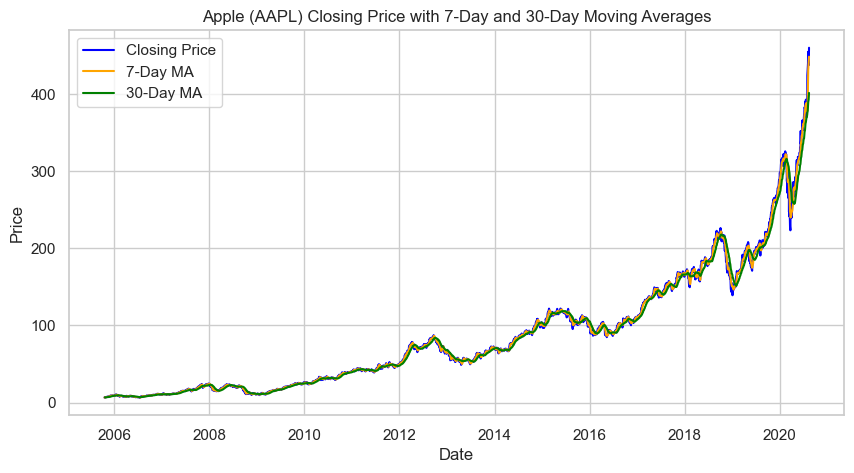

In [40]:
print("29) AAPL: Trend and moving averages (7-day, 30-day)")

aapl = data['AAPL'].copy()

close_col = None
for col in aapl.columns:
    if 'close' in col.lower():  
        close_col = col
        break

if close_col is None:
    raise KeyError("No column related to 'Close' found in AAPL dataset.")

aapl['MA7'] = aapl[close_col].rolling(7, min_periods=1).mean()
aapl['MA30'] = aapl[close_col].rolling(30, min_periods=5).mean()

plt.figure(figsize=(10, 5))
plt.plot(aapl['Date'], aapl[close_col], label='Closing Price', color='blue')
plt.plot(aapl['Date'], aapl['MA7'], label='7-Day MA', color='orange')
plt.plot(aapl['Date'], aapl['MA30'], label='30-Day MA', color='green')
plt.title('Apple (AAPL) Closing Price with 7-Day and 30-Day Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


30) Company with strongest long-term upward trend (slope of MA200)
Slopes (price units/day). Higher => stronger upward trend:
TSLA     1.720465
AMZN     1.356884
GOOGL    0.930005
AAPL     0.499416
MSFT     0.215128
FB       0.124147
GS       0.057031
JPM      0.045379
GE      -0.000497
IBM     -0.005116
dtype: float64


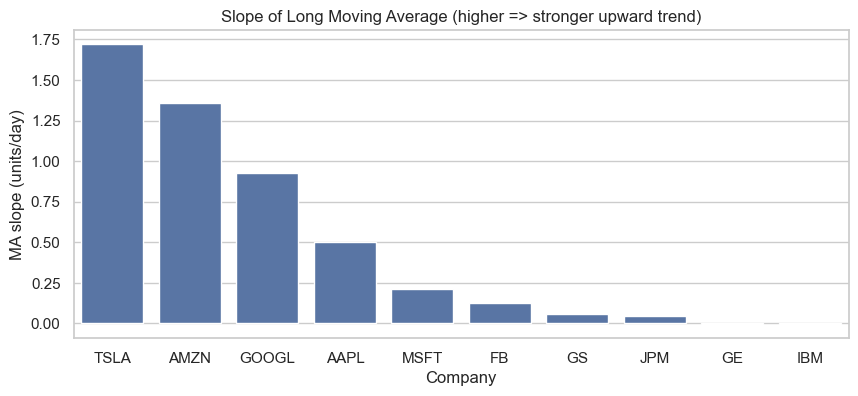

In [41]:
print("\n30) Company with strongest long-term upward trend (slope of MA200)")
ma_slope = {}
for c, df in data.items():
    s = df.set_index('Date')['Close(t)'].dropna()
    if len(s) >= 200:
        ma = s.rolling(200, min_periods=50).mean().dropna()
    elif len(s) >= 100:
        ma = s.rolling(100, min_periods=20).mean().dropna()
    else:
        ma = s.rolling(50, min_periods=5).mean().dropna()
    if len(ma) >= 30:
        y = ma[-252:] if len(ma) >= 252 else ma
        x = np.arange(len(y))
        slope = np.polyfit(x, y.values, 1)[0]
        ma_slope[c] = slope
    else:
        ma_slope[c] = np.nan

ma_slope_s = pd.Series(ma_slope).dropna().sort_values(ascending=False)
print("Slopes (price units/day). Higher => stronger upward trend:")
print(ma_slope_s.round(6))

plt.figure(figsize=(10,4))
sns.barplot(x=ma_slope_s.index, y=ma_slope_s.values)
plt.title('Slope of Long Moving Average (higher => stronger upward trend)')
plt.ylabel('MA slope (units/day)')
plt.xlabel('Company')
plt.show()


31) TSLA: returns vs RSI and MACD (visual comparison)


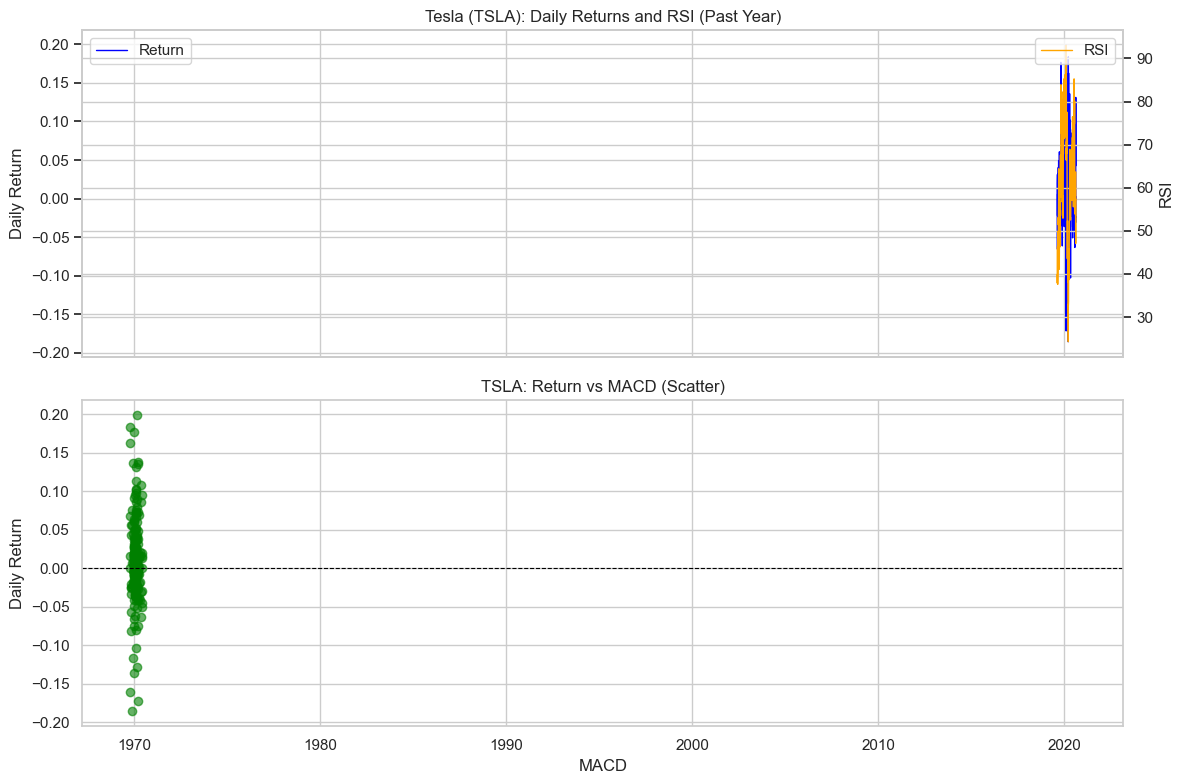

In [42]:
print("\n31) TSLA: returns vs RSI and MACD (visual comparison)")

tsla = data['TSLA'].copy()

def get_col(df, keyword):
    for col in df.columns:
        if keyword.lower() in col.lower():
            return col
    raise KeyError(f"No column found containing '{keyword}'")

return_col = get_col(tsla, 'return')
rsi_col = get_col(tsla, 'rsi')
macd_col = get_col(tsla, 'macd')

tsla['Date'] = pd.to_datetime(tsla['Date'])
tsla_recent = tsla.set_index('Date')

if len(tsla_recent) > 365:
    recent_start = tsla_recent.index.max() - pd.Timedelta(days=365)
    tsla_recent = tsla_recent.loc[tsla_recent.index >= recent_start]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1 = axes[0]
ax1.plot(tsla_recent.index, tsla_recent[return_col], label='Return', color='blue', linewidth=1)
ax1.set_ylabel('Daily Return')
ax2 = ax1.twinx()
ax2.plot(tsla_recent.index, tsla_recent[rsi_col], color='orange', label='RSI', linewidth=1)
ax2.set_ylabel('RSI')
ax1.set_title('Tesla (TSLA): Daily Returns and RSI (Past Year)')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

ax3 = axes[1]
mask = tsla_recent[macd_col].notna() & tsla_recent[return_col].notna()
ax3.scatter(tsla_recent.loc[mask, macd_col], tsla_recent.loc[mask, return_col], alpha=0.6, color='green')
ax3.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax3.set_title('TSLA: Return vs MACD (Scatter)')
ax3.set_xlabel('MACD')
ax3.set_ylabel('Daily Return')

plt.tight_layout()
plt.show()



32) Growth trends: technology vs financial companies (normalized prices)


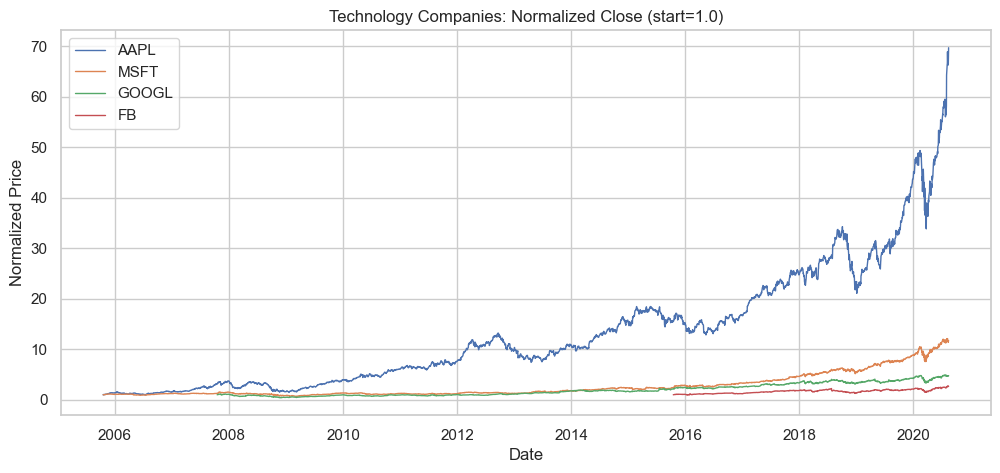

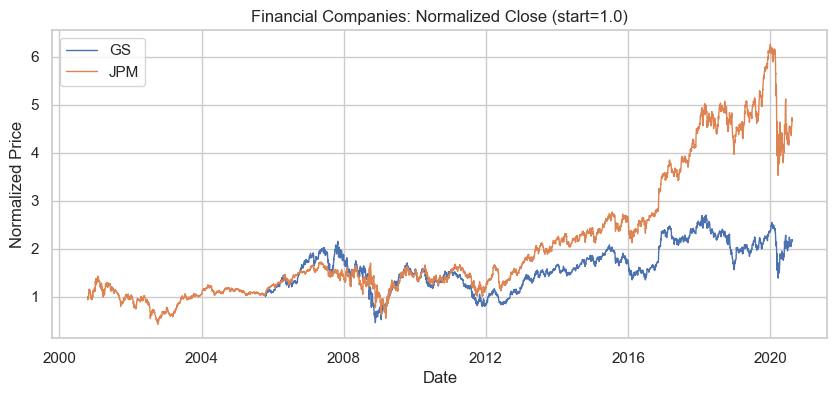

In [43]:
print("\n32) Growth trends: technology vs financial companies (normalized prices)")
tech = ['AAPL','MSFT','GOOGL','FB']
fin = ['GS','JPM']
plt.figure(figsize=(12,5))
for c in tech:
    s = data[c].set_index('Date')['Close(t)'].ffill()
    s = s / s.iloc[0]
    plt.plot(s.index, s.values, label=c, linewidth=1)
plt.title('Technology Companies: Normalized Close (start=1.0)')
plt.xlabel('Date')
plt.ylabel('Normalized Price')
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
for c in fin:
    s = data[c].set_index('Date')['Close(t)'].ffill()
    s = s / s.iloc[0]
    plt.plot(s.index, s.values, label=c, linewidth=1)
plt.title('Financial Companies: Normalized Close (start=1.0)')
plt.xlabel('Date')
plt.ylabel('Normalized Price')
plt.legend()
plt.show()


Yearly average SD20 (sample):
         AAPL     TSLA    GOOGL    MSFT     AMZN      GE      GS     IBM  \
2016   2.6596   9.7527  15.3932  1.0765  19.5478  0.4597  5.0371  2.5490   
2017   2.9101  12.7918  16.4623  1.0109  20.4431  0.4857  4.2909  2.1397   
2018   5.4848  16.8839  30.9721  2.1389  55.2153  0.5235  5.8126  3.0747   
2019   5.7679  14.7596  25.7382  2.4069  43.2980  0.4299  5.2373  2.8621   
2020  13.6082  87.7234  48.0823  6.5284  96.9126  0.5896  9.9788  5.3993   

         JPM      FB  
2016  1.4688  2.7521  
2017  1.5203  2.7399  
2018  2.2622  5.9839  
2019  2.4701  5.3306  
2020  5.0342  9.2439  


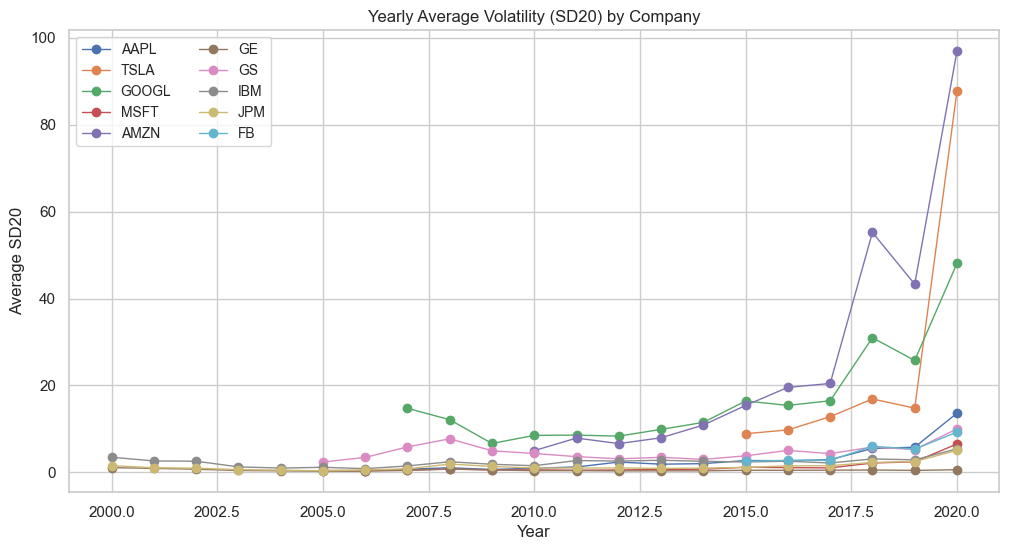

In [44]:
vol_yearly = pd.DataFrame()
for c, df in data.items():
    tmp = df[['Date', 'SD20']].copy()
    tmp['Year'] = tmp['Date'].dt.year
    yearly = tmp.groupby('Year')['SD20'].mean().rename(c)
    vol_yearly = pd.concat([vol_yearly, yearly], axis=1)

vol_yearly = vol_yearly.sort_index()
print("\nYearly average SD20 (sample):")
print(vol_yearly.tail(5).round(4))

plt.figure(figsize=(12,6))
for c in vol_yearly.columns:
    plt.plot(vol_yearly.index, vol_yearly[c], marker='o', label=c, linewidth=1)
plt.title("Yearly Average Volatility (SD20) by Company")
plt.xlabel("Year")
plt.ylabel("Average SD20")
plt.legend(ncol=2, fontsize='small')
plt.grid(True)
plt.show()


Annualized Sharpe Ratio (proxy) by company
AMZN     3.7254
AAPL     3.3271
TSLA     2.9694
FB       2.7897
MSFT     2.6676
GOOGL    1.8514
JPM      1.2097
GS       1.0172
IBM      0.7503
GE      -0.2413
dtype: float64


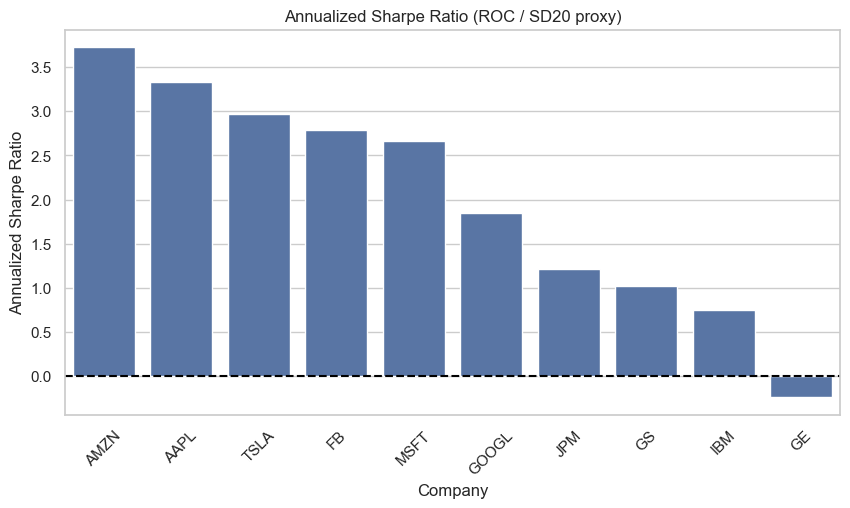

In [45]:
from math import sqrt
sharpe_daily = {}
for c, df in data.items():
    roc = df['ROC'].dropna()
    if len(roc) < 10:
        sharpe_daily[c] = np.nan
    else:
        mu = roc.mean()
        sigma = roc.std()
        if sigma == 0 or np.isnan(sigma):
            sharpe_daily[c] = np.nan
        else:
            sharpe_daily[c] = mu / sigma

sharpe_annual = {c: (sharpe_daily[c] * sqrt(252)) if not np.isnan(sharpe_daily[c]) else np.nan for c in sharpe_daily}

sharpe_series = pd.Series(sharpe_annual).sort_values(ascending=False)
print("Annualized Sharpe Ratio (proxy) by company")
print(sharpe_series.round(4))

plt.figure()
sns.barplot(x=sharpe_series.index, y=sharpe_series.values)
plt.title("Annualized Sharpe Ratio (ROC / SD20 proxy)")
plt.ylabel("Annualized Sharpe Ratio")
plt.xlabel("Company")
plt.xticks(rotation=45)
plt.axhline(0, color='black', linestyle='--')
plt.show()

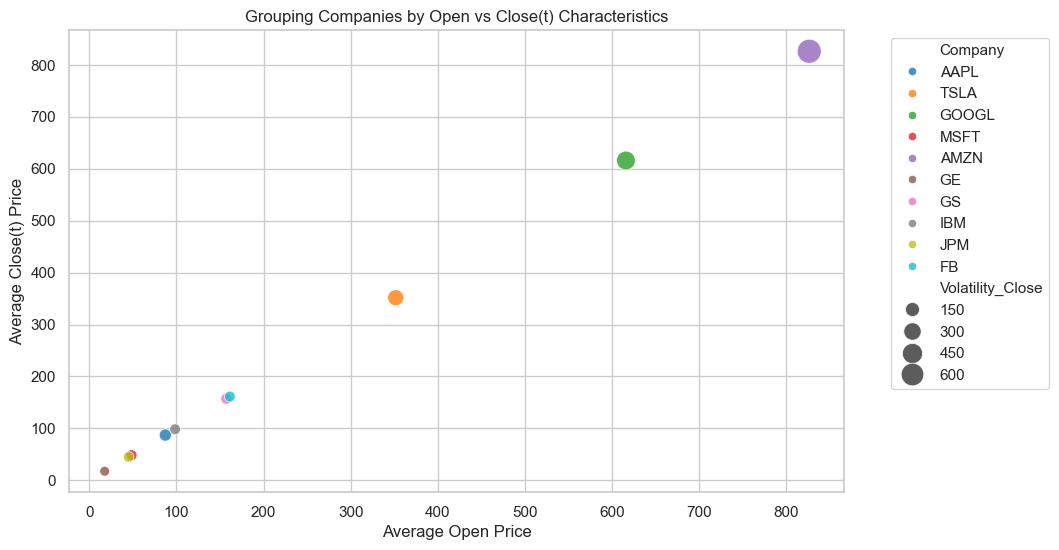

In [46]:
open_close_stats = []
for c, df in data.items():
    if 'Open' in df.columns and 'Close(t)' in df.columns:
        df = df.dropna(subset=['Open', 'Close(t)'])
        avg_open = df['Open'].mean()
        avg_close = df['Close(t)'].mean()
        vol_open = df['Open'].std()
        vol_close = df['Close(t)'].std()
        open_close_stats.append({
            'Company': c,
            'Avg_Open': avg_open,
            'Avg_Close': avg_close,
            'Volatility_Open': vol_open,
            'Volatility_Close': vol_close
        })

stats_df = pd.DataFrame(open_close_stats)


plt.figure(figsize=(10,6))
sns.scatterplot(
    x='Avg_Open', 
    y='Avg_Close', 
    size='Volatility_Close', 
    hue='Company', 
    data=stats_df, 
    palette='tab10', 
    sizes=(50, 300), 
    alpha=0.8
)
plt.title("Grouping Companies by Open vs Close(t) Characteristics")
plt.xlabel("Average Open Price")
plt.ylabel("Average Close(t) Price")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()



Q37: Golden cross counts (MA50 crossing above MA200) by company
IBM      16
GE       16
JPM      14
MSFT     10
GS       10
GOOGL    10
TSLA      6
AAPL      6
AMZN      5
FB        4
dtype: int64

Q37: Momentum persistence (proportion of days MA50 > MA200) by company
FB       0.8066
AMZN     0.8039
AAPL     0.7835
MSFT     0.7578
GOOGL    0.7163
JPM      0.6301
IBM      0.6006
GS       0.5766
GE       0.5467
TSLA     0.5095
dtype: float64


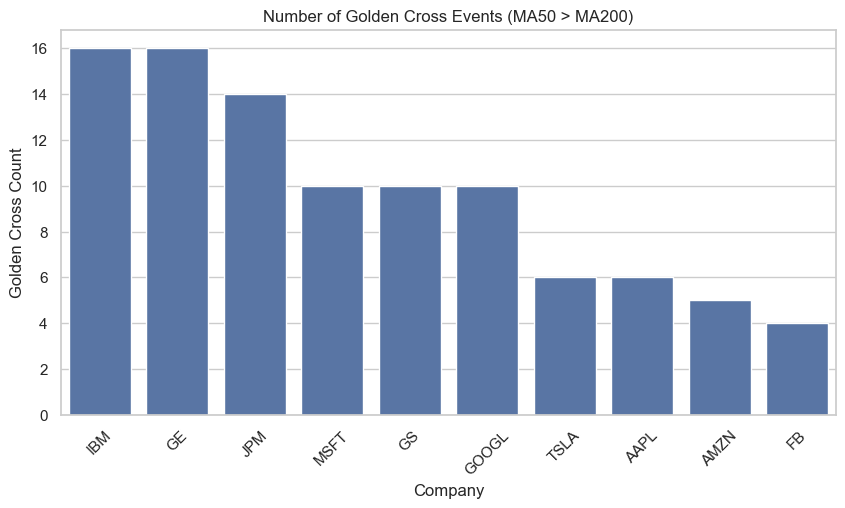

In [47]:
golden_counts = {}
momentum_prop = {}
for c, df in data.items():
    tmp = df[['Date', 'MA50', 'MA200']].dropna().copy()
    if tmp.empty:
        golden_counts[c] = 0
        momentum_prop[c] = np.nan
        continue
    ma50 = tmp['MA50']
    ma200 = tmp['MA200']
    cross = (ma50 > ma200).astype(int)
    golden = int((cross.diff() == 1).sum())
    golden_counts[c] = golden
    momentum_prop[c] = (cross.sum() / len(cross)) if len(cross) > 0 else np.nan

golden_series = pd.Series(golden_counts).sort_values(ascending=False)
momentum_prop_series = pd.Series(momentum_prop).sort_values(ascending=False)

print("\nQ37: Golden cross counts (MA50 crossing above MA200) by company")
print(golden_series)

print("\nQ37: Momentum persistence (proportion of days MA50 > MA200) by company")
print(momentum_prop_series.round(4))

plt.figure()
sns.barplot(x=golden_series.index, y=golden_series.values)
plt.title("Number of Golden Cross Events (MA50 > MA200)")
plt.ylabel("Golden Cross Count")
plt.xlabel("Company")
plt.xticks(rotation=45)
plt.show()

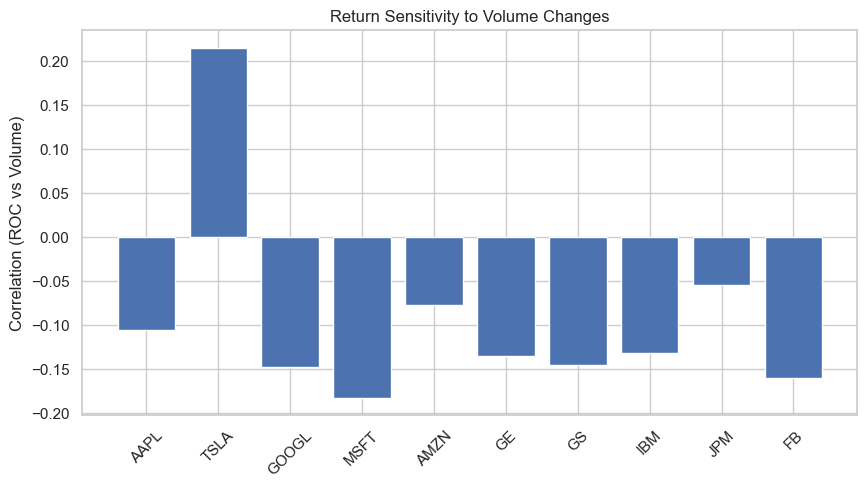

In [48]:
sensitivity = {c: data[c]['ROC'].corr(data[c]['Volume']) for c in data}
plt.bar(sensitivity.keys(), sensitivity.values())
plt.title('Return Sensitivity to Volume Changes')
plt.ylabel('Correlation (ROC vs Volume)')
plt.xticks(rotation=45)
plt.show()


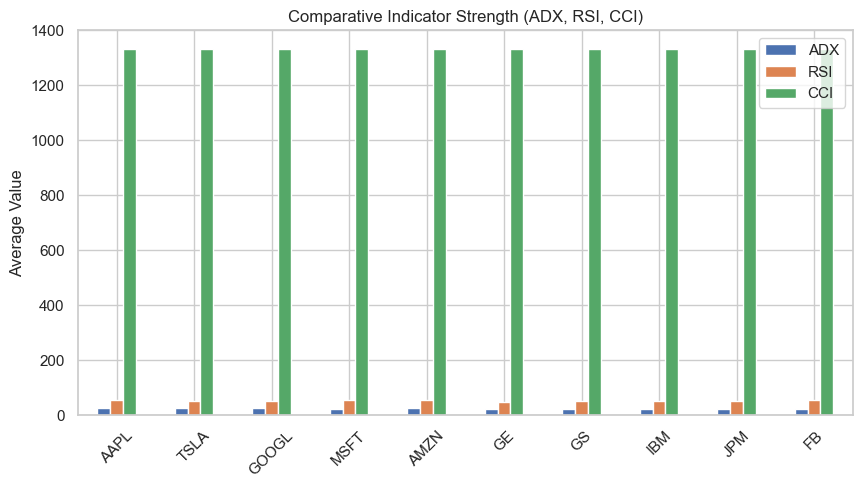

In [49]:
summary = pd.DataFrame({
    'ADX': [data[c]['ADX'].mean() for c in data],
    'RSI': [data[c]['RSI'].mean() for c in data],
    'CCI': [data[c]['CCI'].mean() for c in data]
}, index=data.keys())

summary.plot(kind='bar', figsize=(10,5))
plt.title('Comparative Indicator Strength (ADX, RSI, CCI)')
plt.ylabel('Average Value')
plt.xticks(rotation=45)
plt.show()


C:\Users\e5450\AppData\Local\Temp\ipykernel_16972\4083248740.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Company', y='Market_Correlation', data=market_df, palette='viridis')


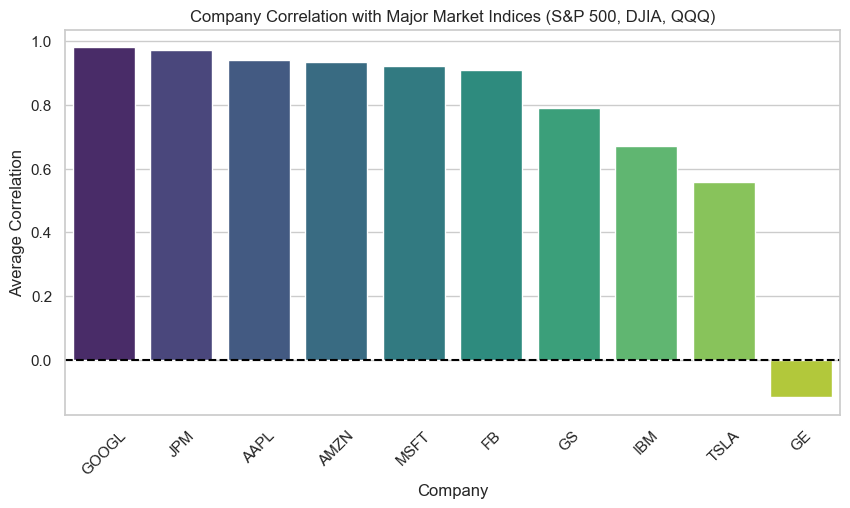

Average correlation of company closing prices with major market indices:

  Company  Market_Correlation
2   GOOGL               0.981
8     JPM               0.972
0    AAPL               0.942
4    AMZN               0.935
3    MSFT               0.921
9      FB               0.909
6      GS               0.790
7     IBM               0.672
1    TSLA               0.558
5      GE              -0.119


In [50]:
market_influence = {}

for c, df in data.items():
    cols = ['Close(t)', 'SnP_Close', 'DJIA_Close', 'QQQ_Close']
    if all(col in df.columns for col in cols):
        corr_snp = df['Close(t)'].corr(df['SnP_Close'])
        corr_djia = df['Close(t)'].corr(df['DJIA_Close'])
        corr_qqq = df['Close(t)'].corr(df['QQQ_Close'])
        avg_corr = np.nanmean([corr_snp, corr_djia, corr_qqq])
        market_influence[c] = avg_corr

market_df = pd.DataFrame(list(market_influence.items()), columns=['Company', 'Market_Correlation'])
market_df = market_df.sort_values(by='Market_Correlation', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x='Company', y='Market_Correlation', data=market_df, palette='viridis')
plt.title("Company Correlation with Major Market Indices (S&P 500, DJIA, QQQ)")
plt.ylabel("Average Correlation")
plt.xlabel("Company")
plt.xticks(rotation=45)
plt.axhline(0, color='black', linestyle='--')
plt.show()

print("Average correlation of company closing prices with major market indices:\n")
print(market_df.round(3))


C:\Users\e5450\AppData\Local\Temp\ipykernel_16972\2041445910.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Company', y='Volume-Volatility Corr', data=corr_df, palette='coolwarm')


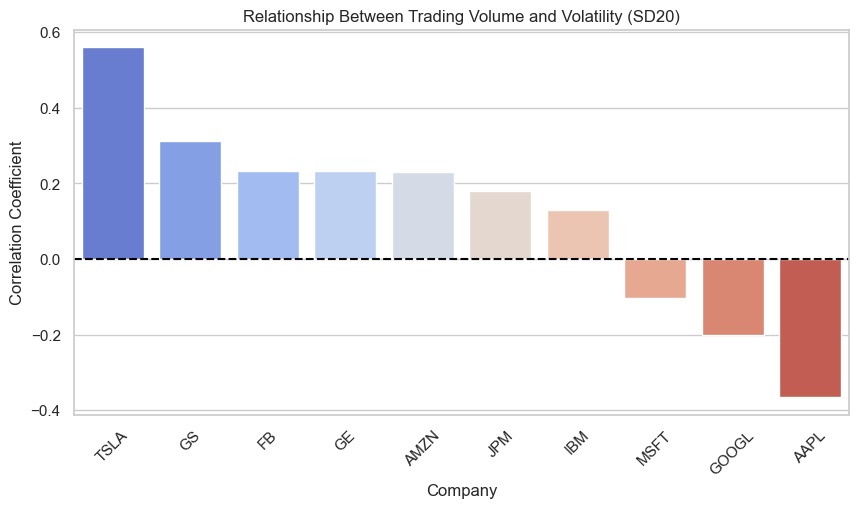

Volume–Volatility correlation by company:

  Company  Volume-Volatility Corr
1    TSLA                   0.560
6      GS                   0.311
9      FB                   0.233
5      GE                   0.233
4    AMZN                   0.230
8     JPM                   0.179
7     IBM                   0.129
3    MSFT                  -0.104
2   GOOGL                  -0.202
0    AAPL                  -0.366


In [51]:
vol_vol_corr = {}

for c, df in data.items():
    if 'Volume' in df.columns and 'SD20' in df.columns:
        corr = df['Volume'].corr(df['SD20'])
        vol_vol_corr[c] = corr

corr_df = pd.DataFrame(list(vol_vol_corr.items()), columns=['Company', 'Volume-Volatility Corr'])
corr_df = corr_df.sort_values(by='Volume-Volatility Corr', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x='Company', y='Volume-Volatility Corr', data=corr_df, palette='coolwarm')
plt.title("Relationship Between Trading Volume and Volatility (SD20)")
plt.ylabel("Correlation Coefficient")
plt.xlabel("Company")
plt.xticks(rotation=45)
plt.axhline(0, color='black', linestyle='--')
plt.show()

print("Volume–Volatility correlation by company:\n")
print(corr_df.round(3))
